In [ ]:
%pip install -U ddgs

In [ ]:
%pip install langchain_community


In [9]:
from langchain_groq import ChatGroq

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from dotenv import load_dotenv


from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
import requests
import random

In [13]:
search_tool = DuckDuckGoSearchRun(region="us-en")

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}

        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}




@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA')
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=RIMMKTY6ABSBECKY"
    r = requests.get(url)
    return r.json()

In [37]:
from google.colab import userdata
api_key = userdata.get('GROQ_API_KEY1')

In [47]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=api_key,
    verbose=True,
    # other params...
)

In [48]:
tools = [search_tool, get_stock_price, calculator]
llm_with_tools = llm.bind_tools(tools)

In [49]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

In [50]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)


In [51]:
graph.add_edge(START, "chat_node")
graph.add_conditional_edges(
    "chat_node",
    tools_condition,
    {"tools": "tools", END: END},
)
graph.add_edge("tools", "chat_node")

In [52]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "chat_node")
graph.add_conditional_edges(
    "chat_node",
    tools_condition,
    {"tools": "tools", END: END},
)
graph.add_edge("tools", "chat_node")
workflow = graph.compile()

In [53]:
workflow = graph.compile()

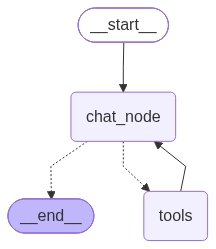

In [54]:
workflow

In [60]:
response = workflow.invoke({'messages' : "what is stock price of apple stock?"})
print(response['messages'][-1])

content='Apple\u202fInc. (AAPL) is currently trading at **$309.35** per share (as of the market close on\u202f2026‑08‑21). The price reflects a slight decline of about\u202f‑0.63\u202f% from the previous close of $311.30.' additional_kwargs={'reasoning_content': 'We need to respond with the stock price. Provide price and maybe context.'} response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 395, 'total_tokens': 480, 'completion_time': 0.179256643, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.019153922, 'prompt_tokens_details': None, 'queue_time': 0.168940238, 'total_time': 0.198410565}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_02b0d31eca', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a02aac-b39b-79f0-b85f-e02919786dd0-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 395, 'output_tokens': 85, 'total_tokens': 480, 'output_token_d

             STATE
               │
               ▼
      ┌─────────────────┐
      │   chat_node     │
      │                 │
      │ LLM generates   │
      │ AIMessage       │
      └────────┬────────┘
               │
               ▼
       AIMessage has
        tool_call?
          │
        YES
          │
          ▼
      ┌─────────────────┐
      │     ToolNode    │
      │                 │
      │ executes tool   │
      └────────┬────────┘
               │
               ▼
         ToolMessage
               │
               │ state update
               ▼
      ┌─────────────────┐
      │   chat_node     │
      │                 │
      │ reads updated   │
      │ state           │
      └─────────────────┘

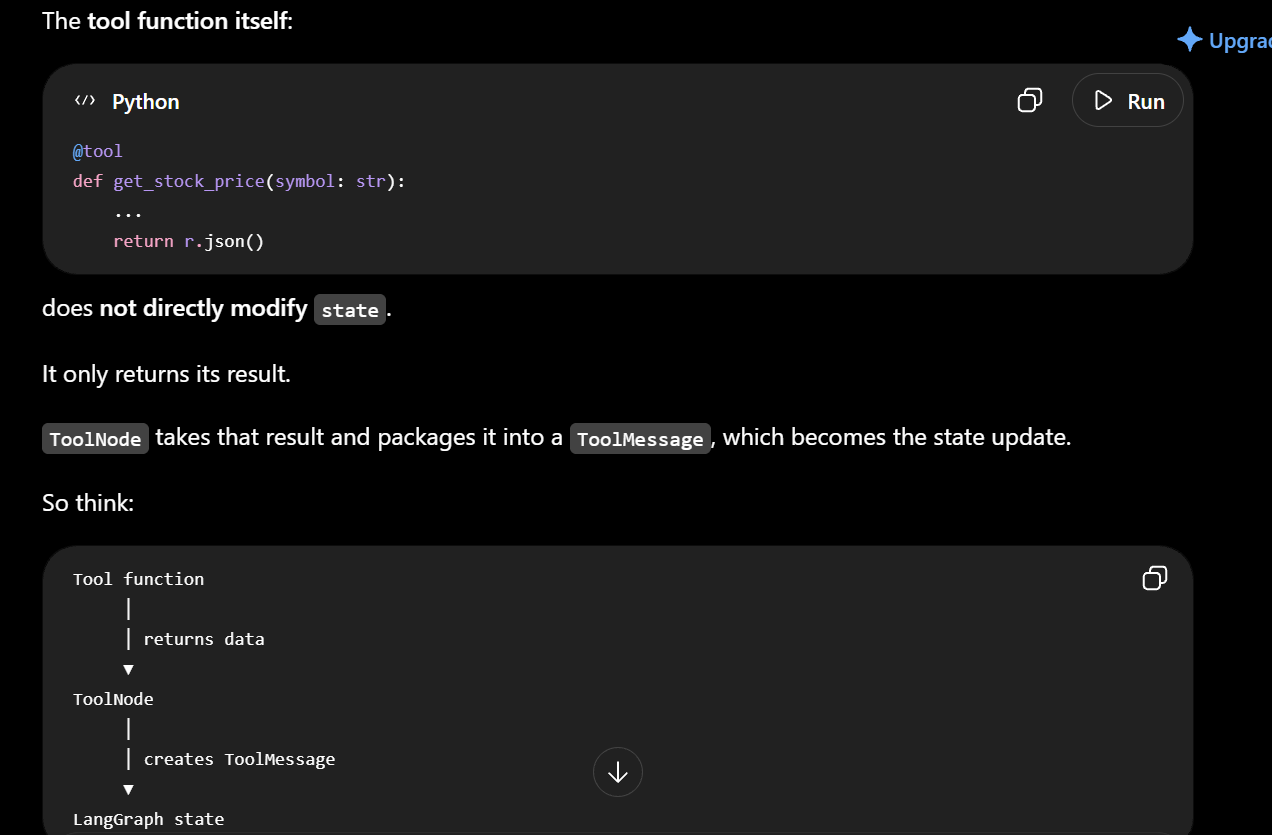